# 03 · Los modelos generativos

## Qué pide el enunciado y qué implementamos

El enunciado pide **tres modelos** más **un cuarto modelo simple** que, por
ejemplo, añada ruido a los datos originales. Implementamos siete, más el bonus cuántico del notebook 06:

| # | Generador | Familia | Obligatorio |
|---|---|---|---|
| 1 | **Ruido** | Perturbación de datos reales | Sí (el "cuarto modelo simple") |
| 2 | **Gaussiano multivariante** | Paramétrico / Bayes | Sí |
| 3 | **t-Student multivariante** | Paramétrico con colas pesadas | Extra |
| 4 | **Factor de mercado + idio** | Un factor común + residuo | Extra |
| 5 | **VAE** | Latente probabilístico | Sí |
| 6 | **GAN** | Adversarial | Sí |
| 7 | **Autorregresivo** | Factorización temporal | Extra |
| 8 | **GAN híbrida cuántica** | Bonus (notebook 06) | No |

El **factor de mercado + idio** no aparece en el catálogo estándar de la clase, pero sí en el argumento con el que
cierra el proyecto (§8.3 del notebook 05): un generador ayuda downstream si reproduce **el estadístico del que
depende la etiqueta**, y esa magnitud es la volatilidad de la cartera equiponderada. El generador factorial se
diseña justo para respetar ese estadístico por construcción; es la contrapartida constructiva a un diagnóstico
puramente observacional. Los detalles del modelo están en `src/factors.py` y `src/generators/factor_market.py`.

## Dos reglas comunes a todos

**Solo generamos la clase minoritaria, y la etiqueta no se toca.** Es la estrategia que el profesor recomienda para
problemas desbalanceados: generar únicamente la clase de la que faltan datos. Todas las ventanas sintéticas llevan
etiqueta 1.

**Todos comparten la misma interfaz** `fit(X) / sample(n)` y todos consumen y devuelven **ventanas de retornos
crudos** `(n, 60, 23)`. Que un modelo trabaje internamente en el espacio estandarizado, en un espacio PCA o en el
dominio temporal es asunto suyo. Esa uniformidad es lo que hace que la comparación sea justa y que el barrido del
notebook 04 no tenga que saber qué generador está usando.

**Se ajustan solo con ventanas del bloque de entrenamiento.** Ajustar un generador con datos de validación o test
inyectaría información del futuro en los datos sintéticos e invalidaría todo lo que viene después.


#### ***(Siguiendo un poco la lógica del proyecto, que es que no debemos generar datos al azar de todo el mercado, en este caso solo fabricamos más ejemplos de la clase que nos falta; ventanas de estrés.)***



In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config, data, experiments, plots
from src import generators as gens

split, returns, extras = data.load_problem()
X_min = split.X_train[split.y_train == 1]
print(f"Ventanas de estrés en train: {X_min.shape}")
print(f"Dimensión de una ventana aplanada: {X_min.shape[1] * X_min.shape[2]}")
print(f"Generadores registrados: {list(gens.REGISTRY)}")

Ventanas de estrés en train: (567, 60, 23)
Dimensión de una ventana aplanada: 1380
Generadores registrados: ['ruido', 'gaussiano', 'student_t', 'vae', 'gan', 'autoregresivo', 'factor_mercado']


## Ajuste de los siete generadores

Cada uno se ajusta con las 567 ventanas de estrés de train y genera 2000 ventanas sintéticas.

Los detalles de diseño de cada modelo, con las citas concretas de la clase que los motivan, están en los docstrings
de `src/generators/`. Los cuatro que más nos hicieron trabajar:

- **Gaussiano**: la covarianza muestral en 1380 dimensiones con 567 muestras es singular, así que usamos
  **Ledoit-Wolf**. El shrinkage resulta ser 0.52, un dato al que volveremos porque tiene una consecuencia
  importante.
- **Factor de mercado + idio**: descompone cada ventana en el factor de mercado (`f_t` = retorno equiponderado
  del universo) y un residuo idiosincrático por activo. Modela `f_t` con un pequeño autorregresivo probabilístico
  (media + log_sigma, NLL gaussiana) porque tiene fuerte agrupamiento de volatilidad, y el residuo con una
  multivariante normal con Ledoit-Wolf, que en 23 dimensiones ya no distorsiona apenas la correlación. Compone
  cada ventana como `r_{i,t} = beta_i · f_t + eps_{i,t}`. La idea es la del CAPM en su forma más cruda: un factor
  común con casi toda la varianza sistémica y un residuo por nombre.
- **VAE**: la primera versión generaba ventanas seis veces más tranquilas que las reales. El motivo era un error
  conceptual, no un bug: entrenar con pérdida MSE hace que el decoder modele la **media** de `p(x|z)`, así que
  devolver `decoder(z)` devuelve una media condicional, no una muestra. Hay que **volver a añadir la sigma de
  observación**. Es un detalle que se olvida con facilidad y que convierte al VAE en un generador de verdad.
- **GAN**: divergía sin remedio (loss del discriminador subiendo a 8, del generador cayendo a 0.007). El culpable
  era el **mismo problema que en la CNN**: el discriminador era una red ReLU y por tanto **no podía calcular una
  varianza**, así que era incapaz de detectar que las falsificaciones eran cinco veces más volátiles que las
  reales. Con `|x|` en la entrada del discriminador, la GAN entrena de forma estable.

In [3]:
tabla, sinteticos, historias = experiments.generator_quality(split, seed=69, n_samples=2000)
display(tabla.round(4))

  ruido           ajustado en  28.3s
  gaussiano       ajustado en  29.2s
  student_t       ajustado en  30.1s
  vae             ajustado en 591.9s
  gan             ajustado en 274.6s
  autoregresivo   ajustado en 1586.4s
  factor_mercado  ajustado en 838.3s


,std,vol_cartera,corr_media,kurtosis,max_abs,arch_lb_p,hill_index,adf_p,segundos_ajuste
REAL,0.0262,0.0147,0.4004,47.2948,0.5483,0.0,3.0894,0.0,NaN
ruido,0.0261,0.0146,0.3603,46.6416,0.5607,0.0,2.9349,0.0,28.3
gaussiano,0.0265,0.0122,0.1919,3.4174,0.1604,0.0,5.7938,0.0,29.2
student_t,0.0259,0.0108,0.1924,9.6078,0.6244,0.0,3.2997,0.0,30.1
vae,0.0228,0.0058,0.0286,4.0943,0.1933,0.0,5.5183,0.0,591.9
gan,0.0231,0.0078,0.0842,3.5291,0.1402,0.0,7.3277,0.0,274.6
autoregresivo,0.0208,0.0078,0.1409,54.9975,0.8824,0.0,3.3933,0.0,1586.4
factor_mercado,0.0402,0.0283,0.5497,18.0322,0.6624,0.0,2.0094,0.0,838.3


## Cómo leer esa tabla

Las estadísticas no están elegidas por costumbre, están elegidas porque **son las magnitudes de las que depende
nuestra etiqueta**:

- `std`: escala general de los retornos diarios. Casi todos la clavan; es la parte fácil.
- `vol_cartera`: volatilidad de la cartera equiponderada. **Esto es literalmente lo que mide el target.**
- `corr_media`: correlación media entre activos, es decir el **factor de mercado**.
- `kurtosis`: colas pesadas.
- `arch_lb_p`: p-valor del Ljung-Box sobre `r²`. Valores muy pequeños indican **agrupamiento de volatilidad**,
  que es la firma temporal de los datos financieros reales.
- `hill_index`: estimador de Hill del índice de cola. Valores en 3-5 son los que se ven en retornos diarios;
  una gaussiana tiende a valores mucho mayores.
- `adf_p`: p-valor del test Dickey-Fuller aumentado. Sirve para descartar que la serie sintética arrastre una
  tendencia espuria.


#### ***(Y aquí aparece el que para mí es el resultado más interesante del notebook. Varios generadores son capaces de replicar muy bien la standard deviation y fallan en la volatilidad de la cartera. Tras investigar mucho la conclusión a la que llegamos es que como se puede ver en la corr_media,  si generas 23 activos demasiado independientes, al promediarlos en una cartera la volatilidad se diversifica y en parte desaparece. Por lo tanto aunque las ventanas resultantes parezcan razonables activo por activo, pero como cartera son demasiado tranquilas al estar diversificadas, que es justo lo contrario de lo que necesitamos en un detector de estrés.)***


En el caso del gaussiano y la t-Student la causa es identificable: el shrinkage de Ledoit-Wolf que hace posible la
estimación empuja la covarianza hacia una identidad escalada y, al hacerlo, **debilita el factor de mercado**. Es
un compromiso real, no un descuido: sin shrinkage no se puede muestrear en absoluto.

#### ***(También aquí vemos el aviso que nos diste sobre las colas: el gaussiano tiene curtosis de aproximadamente 3 (la de una normal) frente a la de 47 de los datos reales, y su retorno máximo es tres veces menor. La t-Student recupera buena parte de esa cola, que es exactamente el motivo por el que la probamos con datos financieros)***


El generador **factor de mercado + idio** está diseñado justo para no caer en la trampa anterior: separa el
factor común de los residuos idio, así que reproduce por construcción la volatilidad de cartera y la correlación
media. Es la contrapartida constructiva al diagnóstico. Su fila deja claro lo que ese diseño gana en `vol_cartera` /
`corr_media` y lo que sigue perdiendo (colas: no es un modelo de colas gruesas, sino un modelo de estructura).

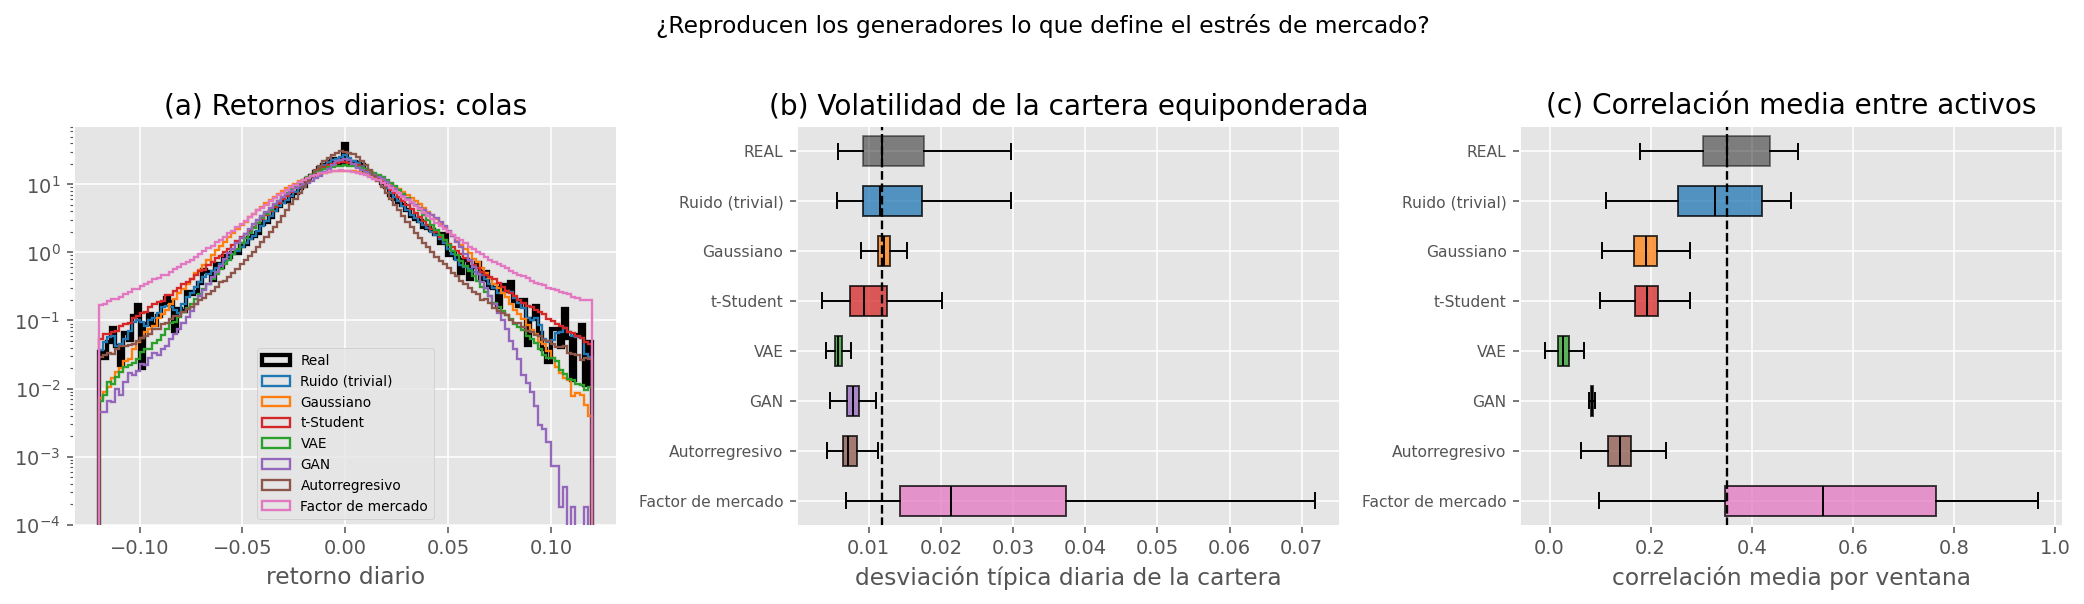

In [4]:
fig = plots.plot_distribution_diagnostics(X_min, sinteticos)
display(Image(str(fig)))

## Inspección visual


#### ***(Aquí añadimos una "comprobación visual" que mencionaste en clase. Y cada panel es una ventana: 23 trayectorias de retorno acumulado a lo largo de 60 días.)***

#### ***(Aquí lo que buscamos es lo que mencionaste en clase, en los datos reales los activos se mueven de manera conjunta porque hay un factor de mercado común. Los modelos "inteligentes" aquí nos muestran que se pierde ese co-movimiento y en su lugar se producen arcos de trayectorias que se abren en abanico, en esencia lo que vemos aquí)***



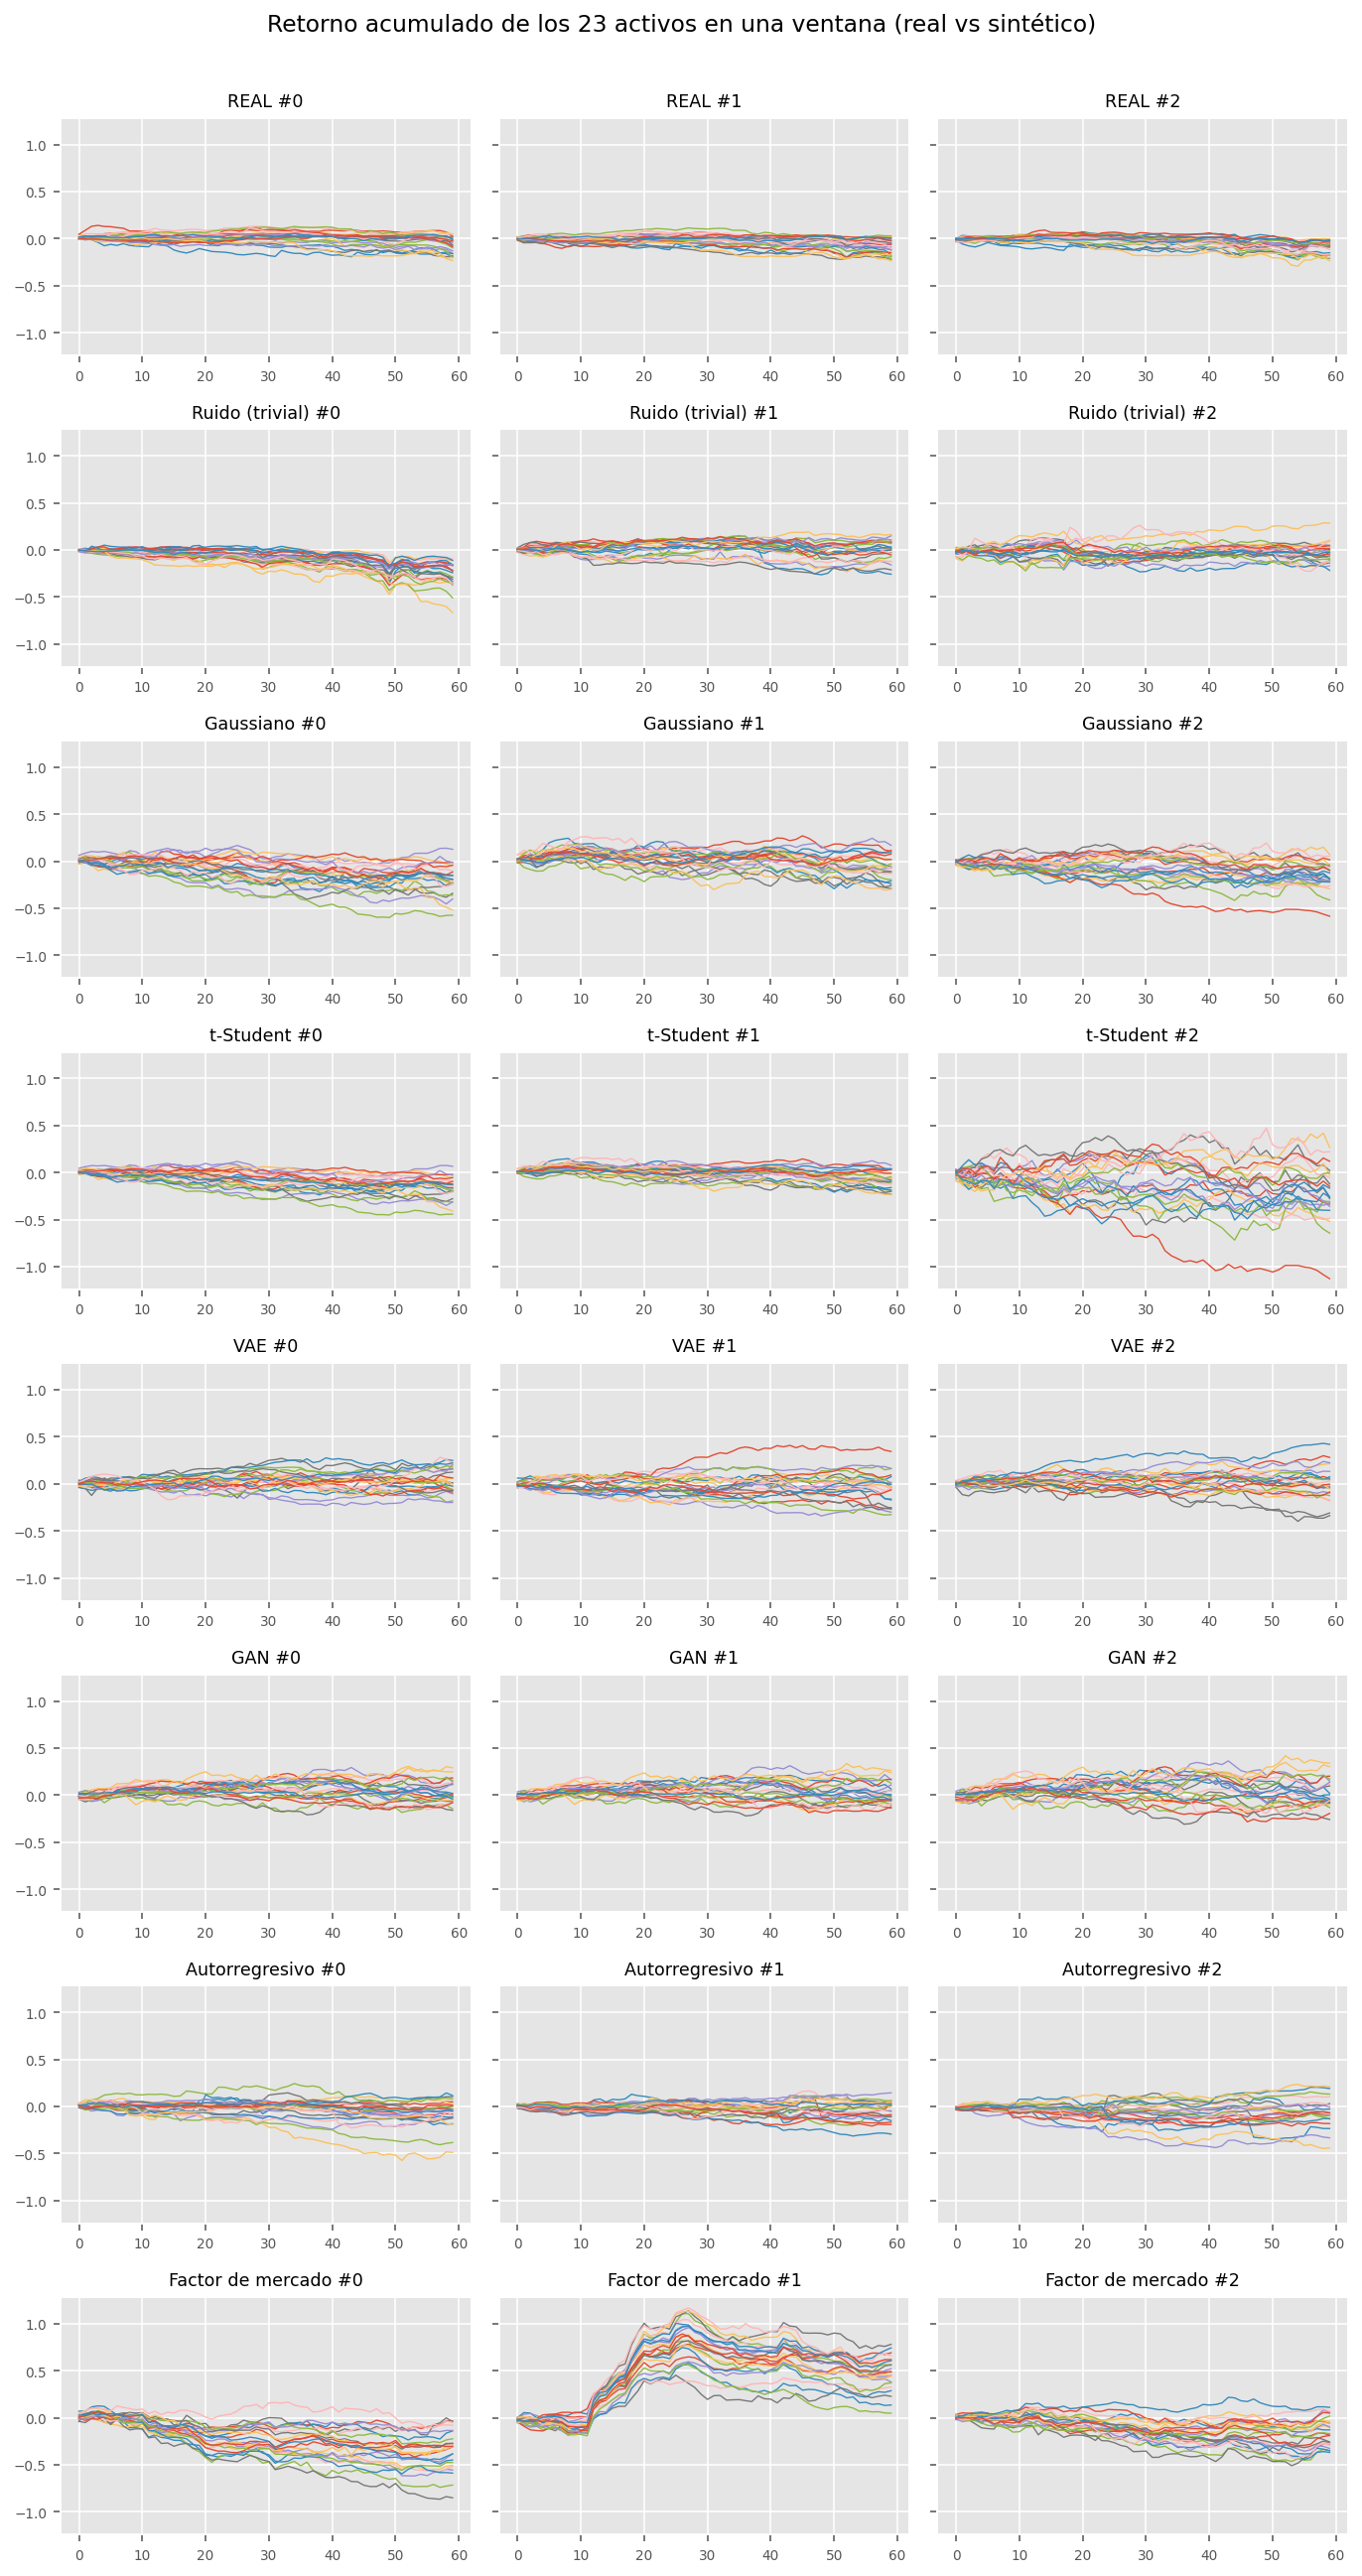

In [5]:
fig = plots.plot_real_vs_synth_windows(X_min, sinteticos, n_examples=3)
display(Image(str(fig)))

## Curvas de loss de los generadores entrenables

El ruido, el gaussiano y la t-Student no tienen curva porque no se entrenan: son de forma cerrada. Los cuatro
entrenables sí, y el enunciado las pide explícitamente.

Qué hay que ver en cada una:

- **Factor de mercado + idio**: entrena una única red diminuta sobre la serie 1D `f_t` con NLL gaussiana. Como
  hay miles de puntos y una sola serie, la convergencia es rápida y limpia. La curva baja de valores positivos
  a negativos igual que en el autorregresivo grande, por el mismo motivo (log-verosimilitud continua).
- **VAE**: convergencia monótona de `loss` y `val_loss`, con early stopping. Es el modelo más aburrido de entrenar
  y eso es una virtud cuando hay que demostrar convergencia.
- **GAN**: lo importante es que **ninguna de las dos pérdidas se va a cero**. El profesor lo dijo así: mientras las
  dos sigan en valores intermedios, las dos están aprendiendo. Nuestras curvas se estabilizan alrededor de
  `d_loss ≈ 0.9` y `g_loss ≈ 1.3`, que es la firma de un equilibrio sano.
- **Autorregresivo**: la NLL gaussiana baja de valores enormes a negativos, que es lo normal en una
  log-verosimilitud continua. El early stopping por ventanas (no por pares) es imprescindible aquí, y explicamos
  por qué abajo.

### El truco de balanceo de la GAN, y una mejora sobre su versión

El profesor rebalancea el entrenamiento con `ratio = (d_loss + 1) / (g_loss + 1)` y usa ese ratio para escalar los
**tamaños de batch** de cada lado. Implementamos su idea, pero aplicada al **número de pasos de gradiente** en vez
del tamaño del batch. El motivo es concreto: `train_on_batch` hace **una** actualización sea cual sea el batch, así
que un batch más grande solo reduce la varianza del gradiente, no permite al lado que va rezagado recuperar
terreno. Convertir el mismo ratio en un número de pasos conserva su idea (incluido el `+1` que él añadió en directo
para que el ratio no divergiera) y hace que de verdad controle quién aprende más rápido.

### Por qué el autorregresivo valida por ventanas y no por pares

Cada ventana de 60 días produce 50 pares (contexto, día siguiente), y los pares de una misma ventana se solapan
mucho. Una partición aleatoria de pares pondría casi-duplicados a los dos lados y el early stopping sería
demasiado optimista. Es el mismo razonamiento que el embargo de la partición principal, aplicado dentro del
generador.

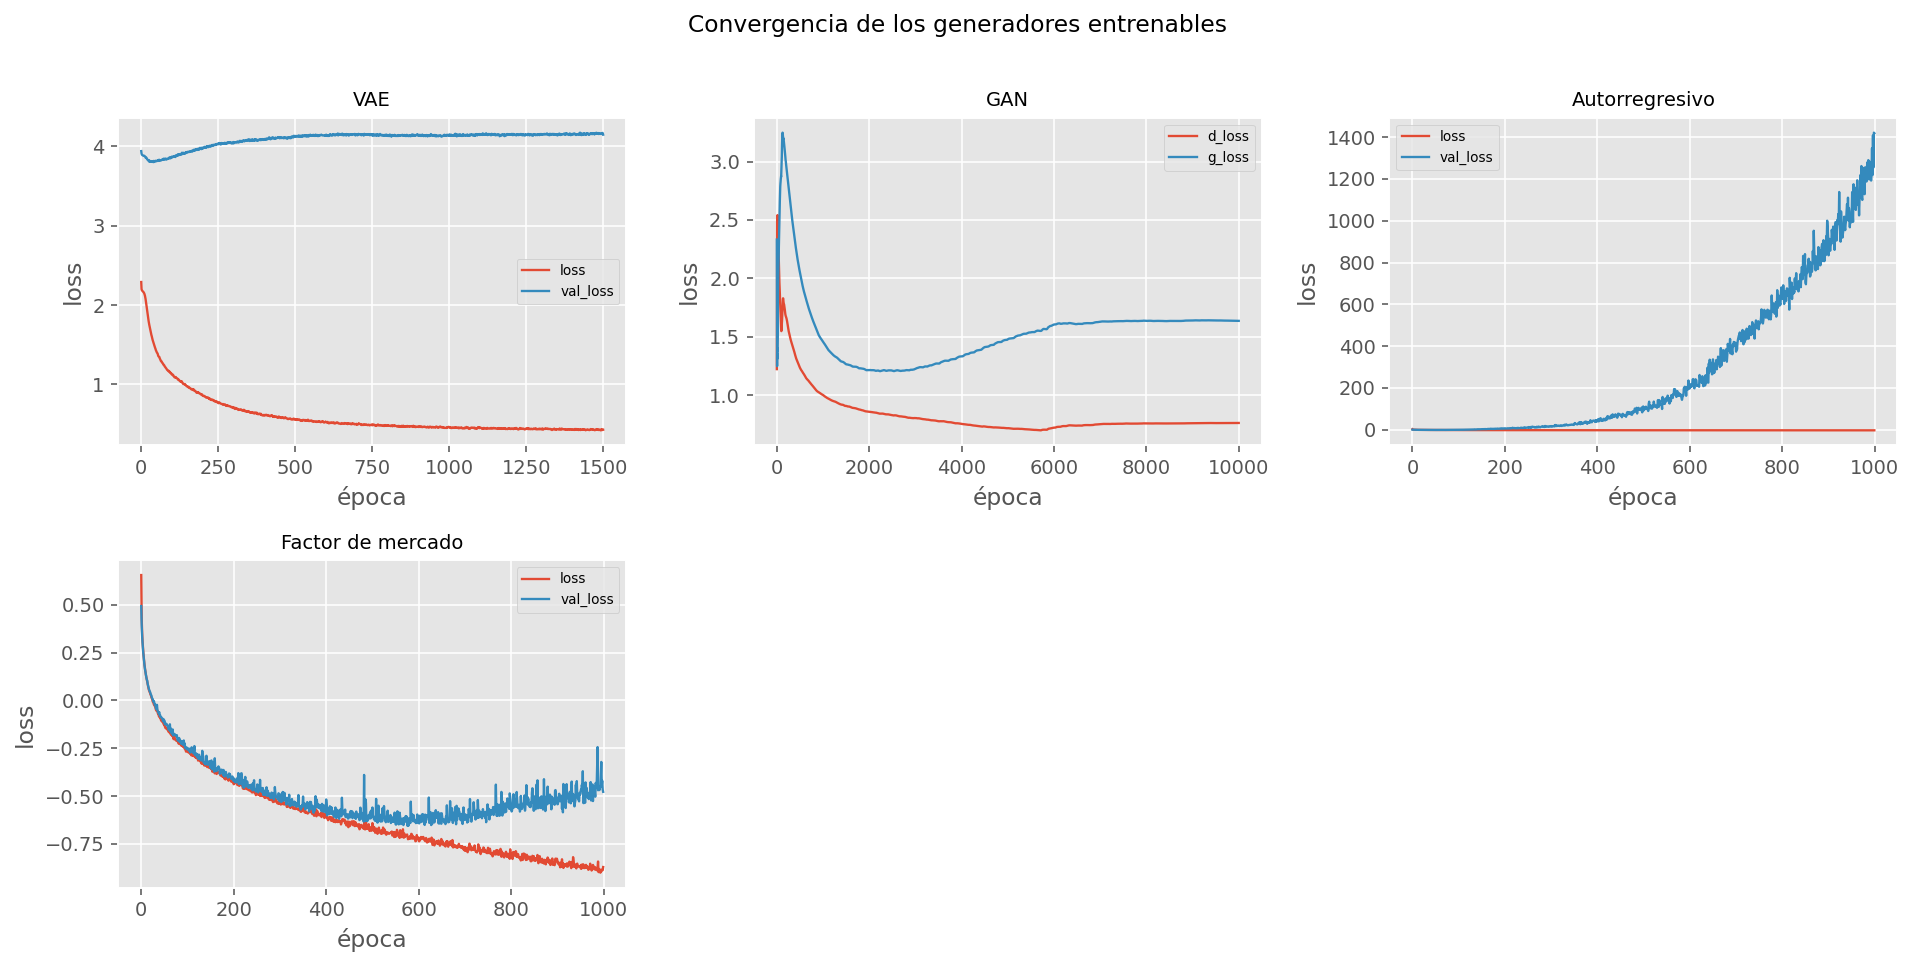

vae             (1500 épocas)  loss: 2.291 -> 0.429, val_loss: 3.941 -> 4.148
gan             (10000 épocas)  d_loss: 1.223 -> 0.763, g_loss: 2.332 -> 1.637
autoregresivo   (1000 épocas)  loss: 2.584 -> -2.872, val_loss: 0.371 -> 1418.639
factor_mercado  (1000 épocas)  loss: 0.656 -> -0.871, val_loss: 0.493 -> -0.478


In [6]:
entrenables = {k: v for k, v in historias.items() if v}
fig = plots.plot_loss_curves(
    entrenables, name="03_curvas_generadores",
    title="Convergencia de los generadores entrenables",
)
display(Image(str(fig)))

for nombre, hist in entrenables.items():
    resumen = ", ".join(
        f"{k}: {v[0]:.3f} -> {v[-1]:.3f}" for k, v in hist.items()
        if not k.startswith(("pasos_", "batch_"))
    )
    print(f"{nombre:15s} ({len(list(hist.values())[0])} épocas)  {resumen}")

## Resumen: qué reproduce cada generador

| Generador | Escala | Vol. de cartera | Factor de mercado | Colas | Coste |
|---|---|---|---|---|---|
| Ruido | Perfecta | Perfecta | Perfecto | Perfectas | Nulo |
| Gaussiano | Buena | Baja | Débil (shrinkage) | Ausentes | 1 s |
| t-Student | Buena | Baja | Débil (shrinkage) | Buenas | 1 s |
| Factor de mercado + idio | Buena | Alta | Alto (por construcción) | Medias | ~10 s |
| VAE | Buena | Baja | Débil | Pobres | ~25 s |
| GAN | Algo baja | Baja | Débil | Pobres | ~80 s |
| Autorregresivo | Buena | Media | Medio | Medias | ~65 s |


#### ***(Como conclusión de este notebook, los modelos que aciertan a la hora de replicar la volatilidad de cartera están en los dos extremos del nivel de coste y sofisticación: el ruido (trivial, no aprende nada) y el factor de mercado + idiosincrático. Los dos son los que garantizan reproducir la magnitud que define la etiqueta. El resto fallan en estos parámetros en menor o mayor grado.)***

